Purpose: Examine results of expression partitioning using HybridExpress.<br>
Author: Anna Pardo<br>
Date initiated: Feb. 15, 2026

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.patches as mpatches

In [2]:
# load results dataframe
res = pd.read_csv("./hybexp_partitiongenes_bygttreat.txt",sep="\t",header="infer")
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat
0,recip_syn1000,1,ADD,6.110441,-0.780159,18_D
1,recip_syn10003,1,ADD,3.313729,-0.887941,18_D
2,recip_syn10008,1,ADD,1.461161,-0.976261,18_D
3,recip_syn10061,1,ADD,2.826917,-1.349656,18_D
4,recip_syn10063,1,ADD,1.728989,-2.551956,18_D


In [3]:
res["Class"].unique()

array(['ADD', 'ELD_P2', 'DOWN', 'ELD_P1', 'UP'], dtype=object)

In [4]:
# split genotype & treatment info
gtt = res["genotype_treat"].str.split("_",expand=True)
gtt.head()

,0,1
0,18,D
1,18,D
2,18,D
3,18,D
4,18,D


In [5]:
gtt.rename(columns={0:"genotype",1:"treat"},inplace=True)
res = pd.concat([res,gtt],axis=1)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat
0,recip_syn1000,1,ADD,6.110441,-0.780159,18_D,18,D
1,recip_syn10003,1,ADD,3.313729,-0.887941,18_D,18,D
2,recip_syn10008,1,ADD,1.461161,-0.976261,18_D,18,D
3,recip_syn10061,1,ADD,2.826917,-1.349656,18_D,18,D
4,recip_syn10063,1,ADD,1.728989,-2.551956,18_D,18,D


In [6]:
# note this is the results from both treatments combined.
# note also: P1 = aloifolia, P2 = filamentosa
# ELD = expression-level dominance

# find the genes that are in the same class (with and without being in the same category) between genotypes
## we will want to know about genotype physiology classification, so load that information

physcat = json.load(open("/home/leviathan22/Yucca_genomics/phys_figures/physiological_CAM_categories.json"))
physcat

{'18': 'C3',
 '48': 'facultative_CAM',
 '43': 'facultative_CAM',
 '70': 'C3',
 '61': 'C3',
 '55': 'C3',
 '1AB': 'possible_fac_CAM',
 '52': 'possible_fac_CAM',
 '16': 'facultative_CAM',
 '56': 'C3',
 '53': 'possible_fac_CAM',
 '51': 'possible_fac_CAM',
 '37': 'possible_fac_CAM',
 'G': 'C3',
 '45': 'C3',
 '19': 'facultative_CAM',
 '13': 'C3',
 'Eudy': 'C3',
 '46': 'possible_fac_CAM',
 '15': 'facultative_CAM',
 '2AB': 'possible_fac_CAM',
 '36': 'C3'}

In [7]:
res["phys"] = res["genotype"].map(physcat)
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,6.110441,-0.780159,18_D,18,D,C3
1,recip_syn10003,1,ADD,3.313729,-0.887941,18_D,18,D,C3
2,recip_syn10008,1,ADD,1.461161,-0.976261,18_D,18,D,C3
3,recip_syn10061,1,ADD,2.826917,-1.349656,18_D,18,D,C3
4,recip_syn10063,1,ADD,1.728989,-2.551956,18_D,18,D,C3


In [8]:
# convert to two dictionaries: one each for class & category with the following structure
## key=class/category, value = {key=genotype, value=gene list}

def make_genelists_dict(colname,res=res):
    outdict = {}
    for i in res[colname].unique():
        df = res[res[colname]==i]
        outdict[i] = {}
        for g in df["genotype_treat"].unique():
            gdf = df[df["genotype_treat"]==g]
            outdict[i][g] = list(gdf["Gene"].unique())
    return outdict

In [9]:
genes_by_class = make_genelists_dict("Class")

In [10]:
genes_by_cat = make_genelists_dict("Category")

In [11]:
genes_by_cat.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

In [12]:
a = [[1,3,5,3],[1,6,78,5],[3,4,5]]

In [13]:
set.intersection(*map(set,a))

{5}

In [14]:
# make a function to get the intersection of all given genotypes for a given treatment
def get_int_all(gtlist,treat,indict):
    # where indict = a subdict of genes_by_cat or genes_by_class
    
    if treat != "both":
        gtl = []
        for i in gtlist:
            gtl.append(i+"_"+treat)
    else:
        gtl = []
        for i in gtlist:
            for j in ["W","D"]:
                gtl.append(i+"_"+j)
        
    # subset indict
    d = {k: indict[k] for k in gtl if k in indict.keys()}
    
    # get list of values & run set.intersection
    intlist = list(set.intersection(*map(set,list(d.values()))))
    return {"genotypes":list(d.keys()),"shared_syntelogs":intlist,"n_shared":len(intlist)}

In [15]:
res["phys"].unique()

array(['C3', 'possible_fac_CAM', 'facultative_CAM'], dtype=object)

In [16]:
# make some genotype lists of interest
allgts = list(res["genotype"].unique())
c3s = list(res[res["phys"]=="C3"]["genotype"].unique())
pfcs = list(res[res["phys"]=="possible_fac_CAM"]["genotype"].unique())
fcs = list(res[res["phys"]=="facultative_CAM"]["genotype"].unique())

In [17]:
# get intersection of all genotypes (control & drought) - by category (more restrictive)
## note 4 genotypes missing from drought: 15, Eudy, 53, 48

allcatw = {}
allcatd = {}
allcatboth = {}
for k in genes_by_cat.keys():
    allcatw[k] = get_int_all(allgts,"W",genes_by_cat[k])
    allcatd[k] = get_int_all(allgts,"D",genes_by_cat[k])
    allcatboth[k] = get_int_all(allgts,"both",genes_by_cat[k])

In [18]:
pd.DataFrame(allcatd)

,1,2,3,4,5,6,7,8,9,10,11,12
genotypes,"[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13...","[18_D, 2AB_D, 1AB_D, 19_D, G_D, 56_D, 36_D, 13..."
shared_syntelogs,"[recip_syn21336, recip_syn11788, recip_syn2793...","[recip_syn15897, recip_syn29731, recip_syn2158...","[recip_syn3610, recip_syn28918, recip_syn22822...","[recip_syn8902, recip_syn9128, recip_syn21071,...","[recip_syn25721, recip_syn7411, recip_syn25999...","[recip_syn6790, recip_syn5382]","[recip_syn26726, recip_syn2572, recip_syn26048...","[recip_syn29070, recip_syn30481, recip_syn2654...","[recip_syn1521, recip_syn21974, recip_syn1448,...","[recip_syn31778, recip_syn19613, recip_syn7072...","[recip_syn28506, recip_syn23833, recip_syn3265...","[recip_syn31917, recip_syn10914, recip_syn3234..."
n_shared,407,56,13,49,6,2,87,52,40,43,30,145


In [19]:
pd.DataFrame(allcatw)

,1,2,3,4,5,6,7,8,9,10,11,12
genotypes,"[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13...","[18_W, 2AB_W, 1AB_W, 19_W, G_W, 56_W, 36_W, 13..."
shared_syntelogs,"[recip_syn11788, recip_syn6160, recip_syn7805,...","[recip_syn15416, recip_syn24203, recip_syn1505...","[recip_syn29864, recip_syn27548, recip_syn1799...","[recip_syn15443, recip_syn18186, recip_syn1029...","[recip_syn7411, recip_syn13508, recip_syn12648...","[recip_syn28419, recip_syn7468, recip_syn23504...","[recip_syn25145, recip_syn11370, recip_syn2932...","[recip_syn8262, recip_syn1107, recip_syn15603,...","[recip_syn31357, recip_syn7915, recip_syn31864...","[recip_syn8044, recip_syn9133, recip_syn24458,...","[recip_syn4649, recip_syn21337, recip_syn18895...","[recip_syn5972, recip_syn9873, recip_syn1816, ..."
n_shared,402,17,20,23,4,8,99,22,36,32,20,168


In [20]:
pd.DataFrame(allcatboth)

,1,2,3,4,5,6,7,8,9,10,11,12
genotypes,"[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,..."
shared_syntelogs,"[recip_syn18246, recip_syn26489, recip_syn8470...","[recip_syn15416, recip_syn24203, recip_syn2779...","[recip_syn28918, recip_syn22822, recip_syn1739...",[recip_syn30023],[recip_syn7411],[recip_syn6790],"[recip_syn6627, recip_syn4948, recip_syn29328,...","[recip_syn4570, recip_syn32140, recip_syn31005...","[recip_syn1716, recip_syn21751, recip_syn10449...","[recip_syn7872, recip_syn15367, recip_syn22872...","[recip_syn25513, recip_syn14424, recip_syn29111]","[recip_syn32341, recip_syn4737, recip_syn22306..."
n_shared,255,5,4,1,1,1,13,8,12,18,3,83


In [21]:
# repeat for each physiological genotype set

c3cat = {"D":{},"W":{},"both":{}}
for k in genes_by_cat.keys():
    for i in c3cat.keys():
        c3cat[i][k] = get_int_all(c3s,i,genes_by_cat[k])

In [22]:
pd.DataFrame(c3cat["both"])

,1,2,3,4,5,6,7,8,9,10,11,12
genotypes,"[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,...","[18_W, 18_D, G_W, G_D, 56_W, 56_D, 36_W, 36_D,..."
shared_syntelogs,"[recip_syn21336, recip_syn11788, recip_syn2793...","[recip_syn31132, recip_syn2140, recip_syn13859...","[recip_syn28918, recip_syn22822, recip_syn4689...","[recip_syn8040, recip_syn29091, recip_syn30023...","[recip_syn25721, recip_syn7411]",[recip_syn6790],"[recip_syn31155, recip_syn5897, recip_syn23075...","[recip_syn18172, recip_syn26766, recip_syn4570...","[recip_syn1521, recip_syn31357, recip_syn28789...","[recip_syn9133, recip_syn15890, recip_syn7872,...","[recip_syn16238, recip_syn31608, recip_syn2551...","[recip_syn10914, recip_syn32341, recip_syn4737..."
n_shared,376,24,8,15,2,1,33,15,29,22,9,122


In [23]:
pfccat = {"D":{},"W":{},"both":{}}
for k in genes_by_cat.keys():
    for i in pfccat.keys():
        pfccat[i][k] = get_int_all(pfcs,i,genes_by_cat[k])

In [24]:
fccat = {"D":{},"W":{},"both":{}}
for k in genes_by_cat.keys():
    for i in fccat.keys():
        fccat[i][k] = get_int_all(fcs,i,genes_by_cat[k])

In [25]:
# repeat by class

allclass = {"D":{},"W":{},"both":{}}
for k in genes_by_class.keys():
    for i in allclass.keys():
        allclass[i][k] = get_int_all(allgts,i,genes_by_class[k])

In [26]:
pd.DataFrame(allclass["both"])

,ADD,ELD_P2,DOWN,ELD_P1,UP
genotypes,"[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,...","[18_W, 18_D, 2AB_W, 2AB_D, 1AB_W, 1AB_D, 19_W,..."
shared_syntelogs,"[recip_syn11788, recip_syn7805, recip_syn32341...","[recip_syn15416, recip_syn25513, recip_syn2420...","[recip_syn18935, recip_syn19613, recip_syn7072...","[recip_syn1716, recip_syn21751, recip_syn30023...","[recip_syn28419, recip_syn4570, recip_syn32140..."
n_shared,338,8,61,13,12


In [27]:
c3class = {"D":{},"W":{},"both":{}}
for k in genes_by_class.keys():
    for i in c3class.keys():
        c3class[i][k] = get_int_all(c3s,i,genes_by_class[k])

In [28]:
pfcclass = {"D":{},"W":{},"both":{}}
for k in genes_by_class.keys():
    for i in pfcclass.keys():
        pfcclass[i][k] = get_int_all(pfcs,i,genes_by_class[k])

In [29]:
fcclass = {"D":{},"W":{},"both":{}}
for k in genes_by_class.keys():
    for i in fcclass.keys():
        fcclass[i][k] = get_int_all(fcs,i,genes_by_class[k])

In [30]:
pd.DataFrame(fcclass["W"])

,ADD,ELD_P2,DOWN,ELD_P1,UP
genotypes,"[19_W, 43_W, 15_W, 48_W]","[19_W, 43_W, 15_W, 48_W]","[19_W, 43_W, 15_W, 48_W]","[19_W, 43_W, 15_W, 48_W]","[19_W, 43_W, 15_W, 48_W]"
shared_syntelogs,"[recip_syn13336, recip_syn11788, recip_syn7696...","[recip_syn14586, recip_syn9899, recip_syn26330...","[recip_syn10445, recip_syn24454, recip_syn7378...","[recip_syn26028, recip_syn12614, recip_syn3099...","[recip_syn21573, recip_syn28689, recip_syn1915..."
n_shared,1281,890,693,1227,364


In [31]:
fcclass["D"]["ADD"].keys()

dict_keys(['genotypes', 'shared_syntelogs', 'n_shared'])

In [32]:
# 2/24: what classes/categories are the CAM genes found in?
## load CAM annotation
cam = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",
                 sep="\t",header="infer")
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [33]:
# load synteny information
syn = pd.read_csv("/home/leviathan22/Yucca_genomics/yucca_synteny/reciprocal_syntelogs_sameinYaYf_long.txt",sep="\t",header="infer")
syn.head()

,GeneID,syntelogID
0,YufilH1000002m.g,recip_syn1
1,Yucal.01G000100.v2.1,recip_syn1
2,YufilH1000007m.g,recip_syn2
3,Yucal.01G000200.v2.1,recip_syn2
4,YufilH1000011m.g,recip_syn3


In [34]:
# merge with CAM annotation
camsyn = cam.merge(syn)
camsyn.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,recip_syn3628
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,recip_syn7619
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya,recip_syn13926
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya,recip_syn6335


In [35]:
# merge with res
camres = camsyn.merge(res.rename(columns={"Gene":"syntelogID"}))
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.944309,1.306498,18_D,18,D,C3
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.814698,1.176887,1AB_D,1AB,D,possible_fac_CAM
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.049999,1.412189,19_D,19,D,facultative_CAM
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.563779,1.925969,G_D,G,D,C3
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,2.221432,2.583621,56_D,56,D,C3


In [36]:
cam_class_sum = camres.groupby(["gene_abbr_unique","Class","treat"]).count().reset_index()[["gene_abbr_unique","Class","treat","genotype"]]

In [37]:
cam_class_sum.head()

,gene_abbr_unique,Class,treat,genotype
0,Ya_BPPC_1,DOWN,D,1
1,Ya_BPPC_1,DOWN,W,10
2,Ya_BPPC_1,ELD_P1,D,4
3,Ya_BPPC_1,ELD_P2,D,3
4,Ya_BPPC_1,UP,D,1


In [38]:
cam_class_sum = cam_class_sum.sort_values(by=["gene_abbr_unique","treat"],ascending=False)

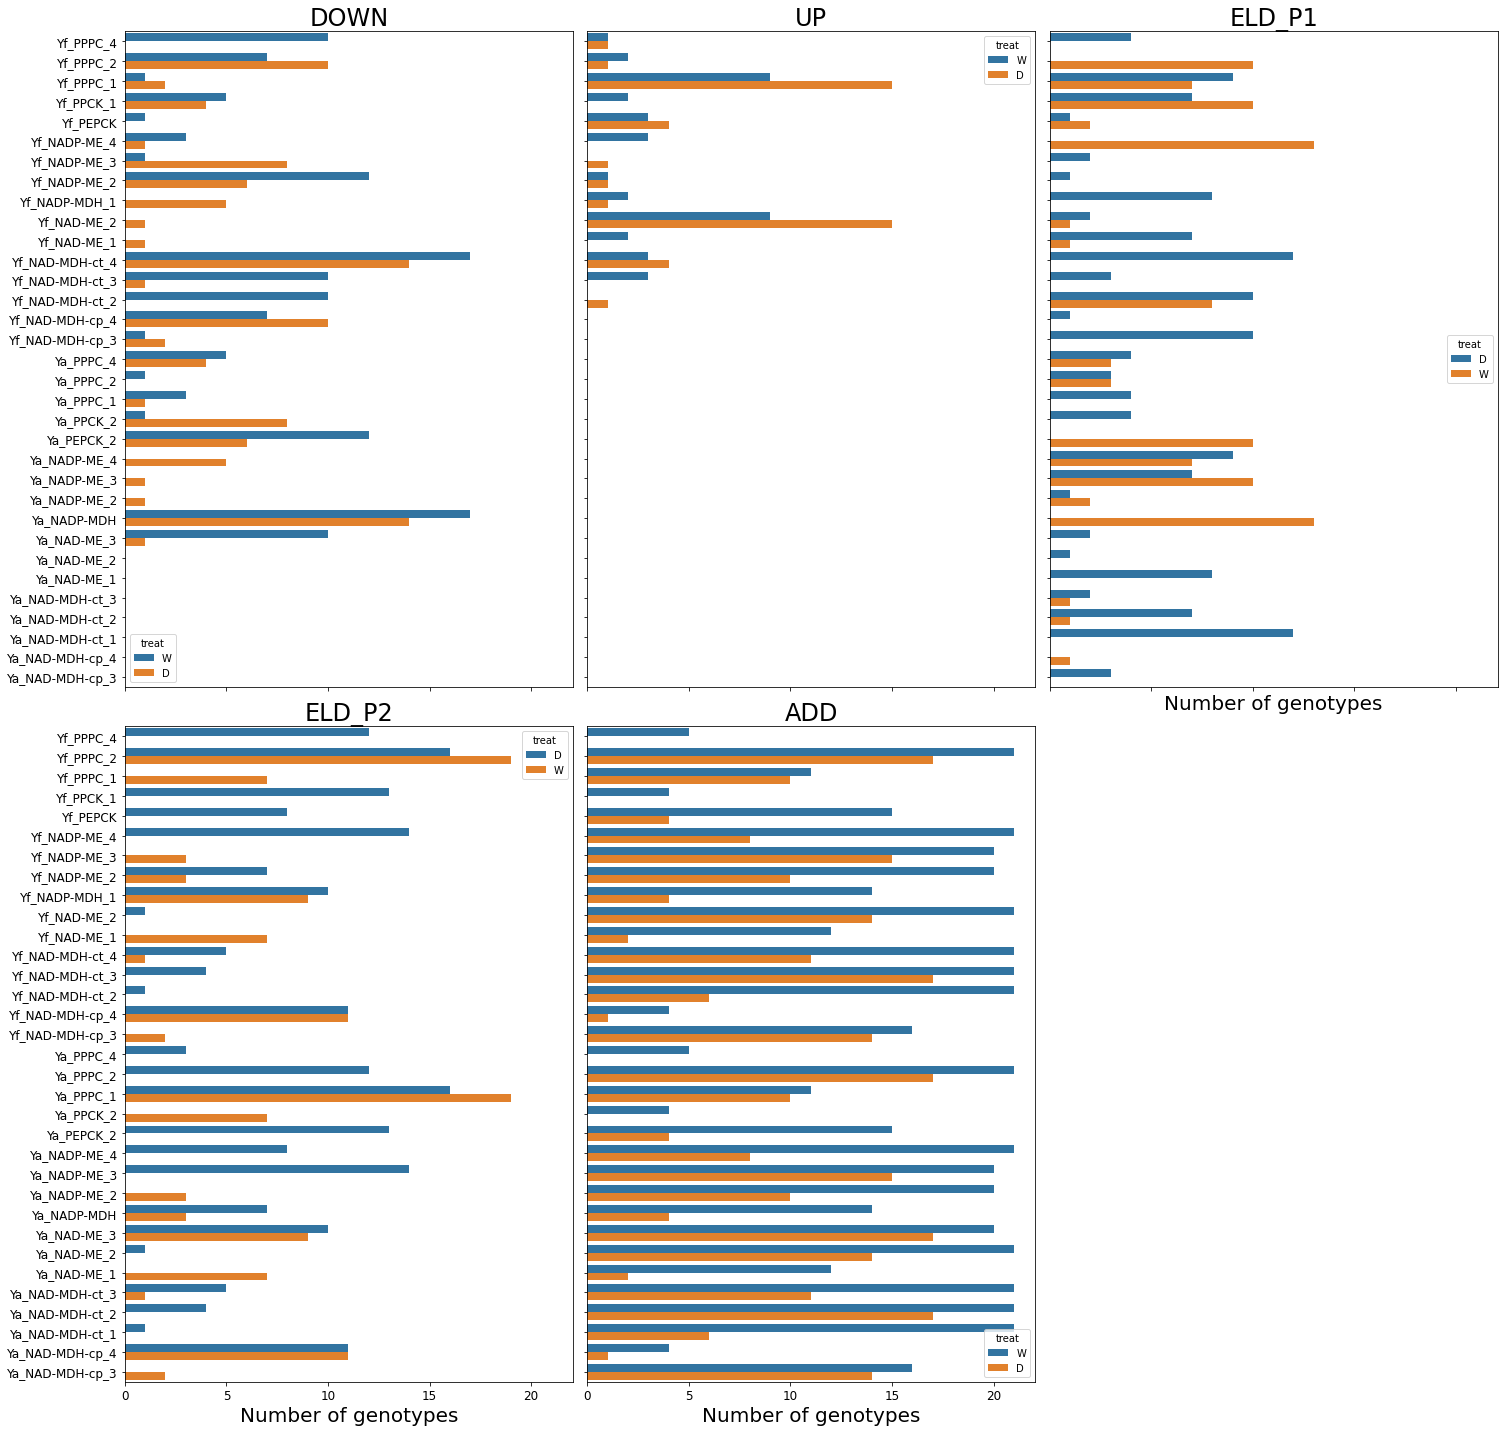

In [39]:
# for each class, plot number of genotype/treatments for each CAM gene
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(21,20),sharex=True,sharey=True)

r=0
c=0
for i in cam_class_sum["Class"].unique():
    df = cam_class_sum[cam_class_sum["Class"]==i]
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="gene_abbr_unique",hue="treat")
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].set_ylabel("")
    ax[r,c].set_xticks(np.arange(0,21,5))
    ax[r,c].tick_params(which="both",labelsize=12)
    
    if (r==0 and c<2):
        ax[r,c].set_xlabel("")
    else:
        ax[r,c].set_xlabel("Number of genotypes",fontsize=20)
    
    
    if c<2:
        c+=1
    else:
        c=0
        r=1
        
fig.tight_layout()
fig.delaxes(ax[1,2])

plt.savefig("./camgenes_exp_partitioning_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_exp_partitioning_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./camgenes_exp_partitioning_summary.svg",dpi=200,bbox_inches="tight")

## Mar. 3: Summarize numbers of genes (overall, not just CAM) by class/category for each genotype/treatment

In [40]:
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,6.110441,-0.780159,18_D,18,D,C3
1,recip_syn10003,1,ADD,3.313729,-0.887941,18_D,18,D,C3
2,recip_syn10008,1,ADD,1.461161,-0.976261,18_D,18,D,C3
3,recip_syn10061,1,ADD,2.826917,-1.349656,18_D,18,D,C3
4,recip_syn10063,1,ADD,1.728989,-2.551956,18_D,18,D,C3


In [53]:
classcounts = res.groupby(["phys","genotype","treat","Class"]).count().reset_index()[["phys","genotype","treat","Class","Gene"]]

In [54]:
catcounts = res.groupby(["phys","genotype","treat","Category"]).count().reset_index()[["phys","genotype","treat","Category","Gene"]]

In [57]:
def subcounts(cdf,colname,colval):
    subdf = cdf[cdf[colname]==colval]
    return subdf.sort_values(by=["treat","phys"],ascending=False)

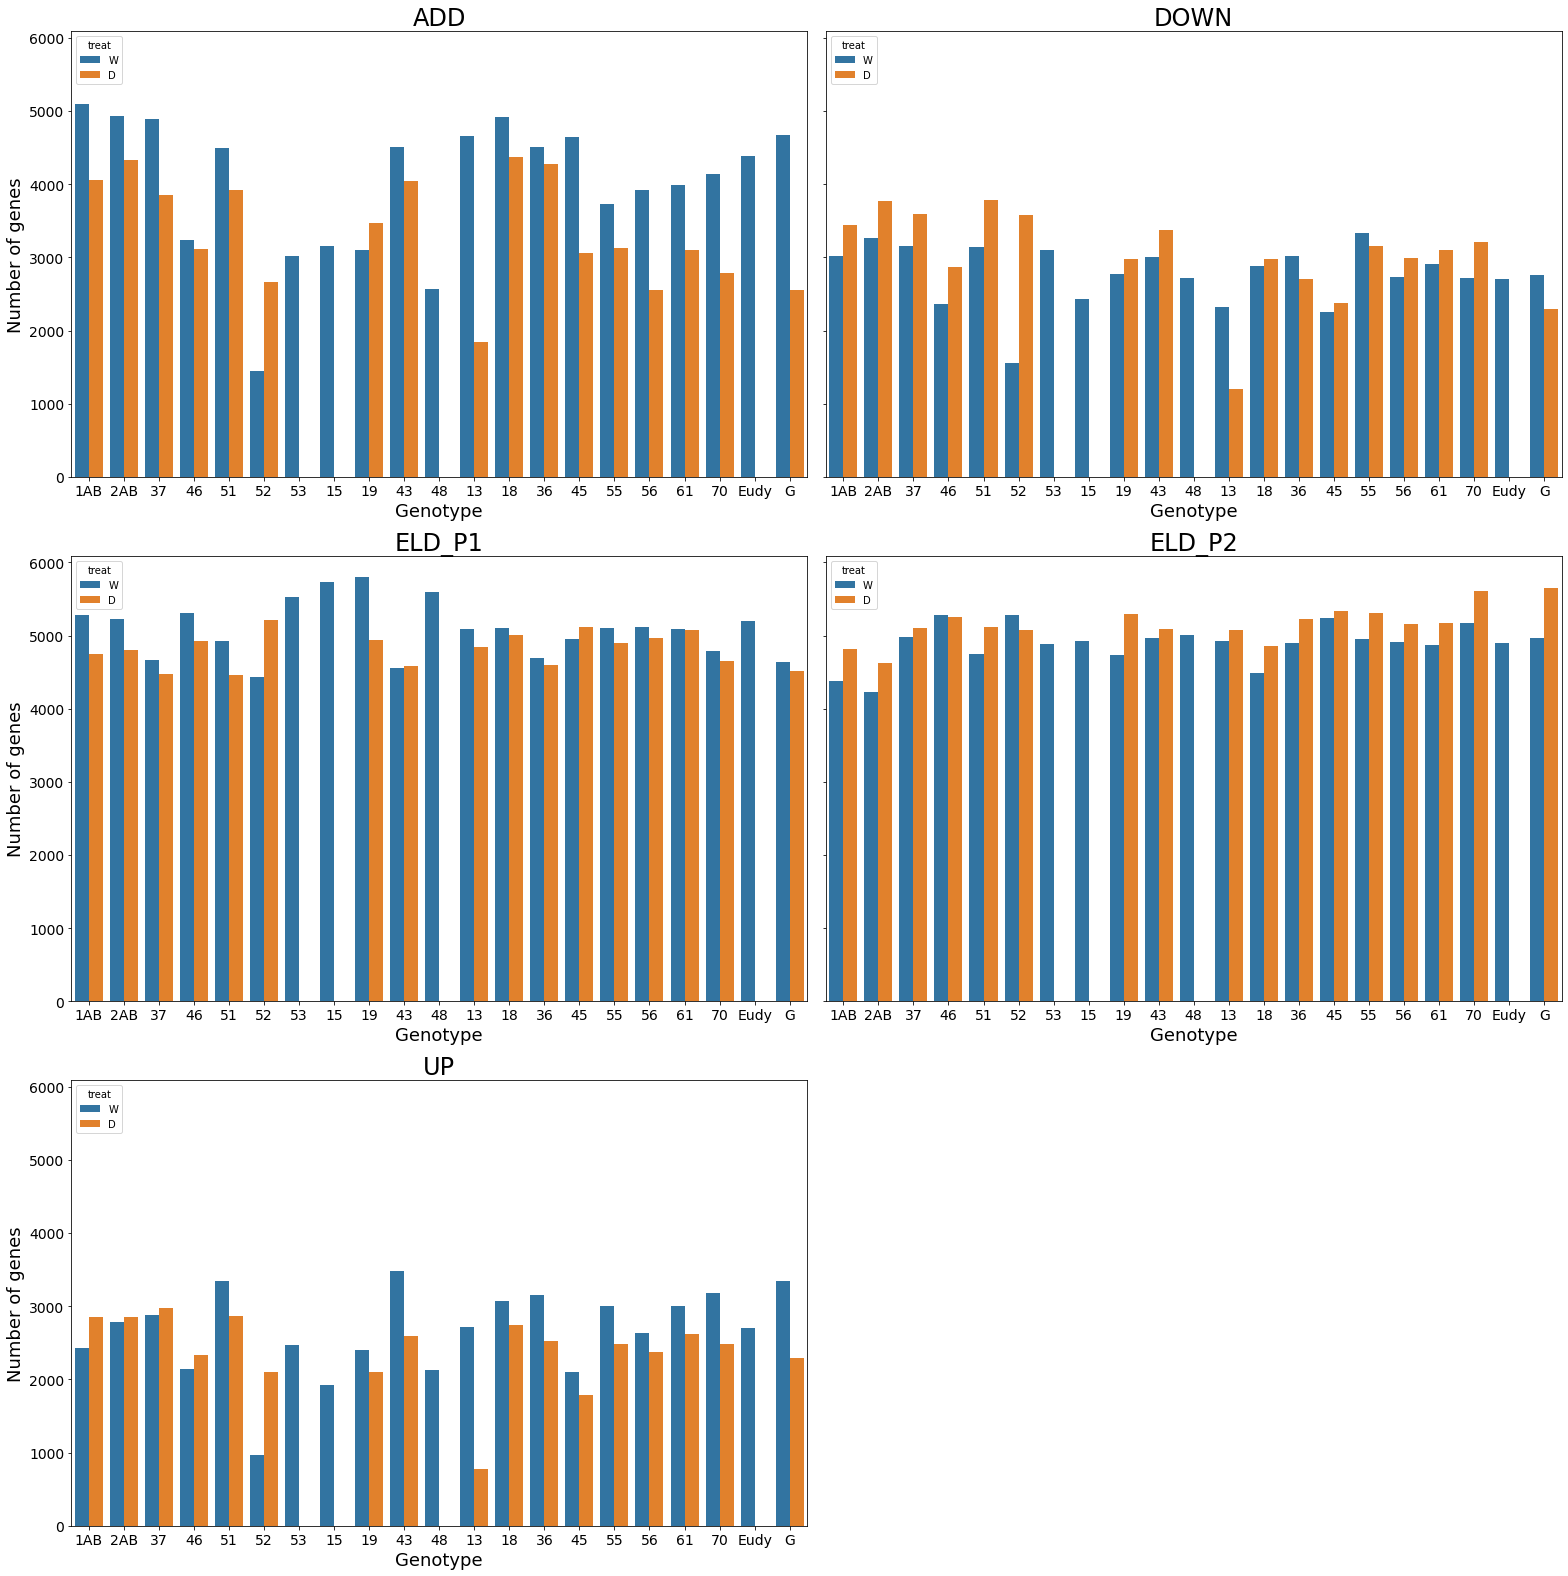

In [72]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)
r=0
c=0
for i in classcounts["Class"].unique():
    df = subcounts(classcounts,"Class",i)
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="Gene",hue="treat")
    ax[r,c].set_title(i,fontsize=24)
    ax[r,c].tick_params(which="both",labelsize=14)
    ax[r,c].set_xlabel("Genotype",fontsize=18)
    if c==0:
        ax[r,c].set_ylabel("Number of genes",fontsize=18)
    else:
        ax[r,c].set_ylabel("")
    
    if c<1:
        c+=1
    else:
        c=0
        r+=1
        
fig.tight_layout()
fig.delaxes(ax[2,1])

plt.savefig("./ngenes_gttreat_class.png",dpi=200,bbox_inches="tight")
plt.savefig("./ngenes_gttreat_class.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ngenes_gttreat_class.svg",dpi=200,bbox_inches="tight")

In [68]:
# repeat this to show numbers of CAM genes by genotype
camres.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,syntelogID,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.944309,1.306498,18_D,18,D,C3
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,0.814698,1.176887,1AB_D,1AB,D,possible_fac_CAM
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.049999,1.412189,19_D,19,D,facultative_CAM
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,1.563779,1.925969,G_D,G,D,C3
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,recip_syn1434,8,UP,2.221432,2.583621,56_D,56,D,C3


In [70]:
camcounts = camres.groupby(["phys","genotype","treat","Class"]).count().reset_index()[["phys","genotype","treat","Class","syntelogID"]]

In [91]:
order = camcounts.sort_values(by=["treat","phys"],ascending=False)["genotype"].unique()

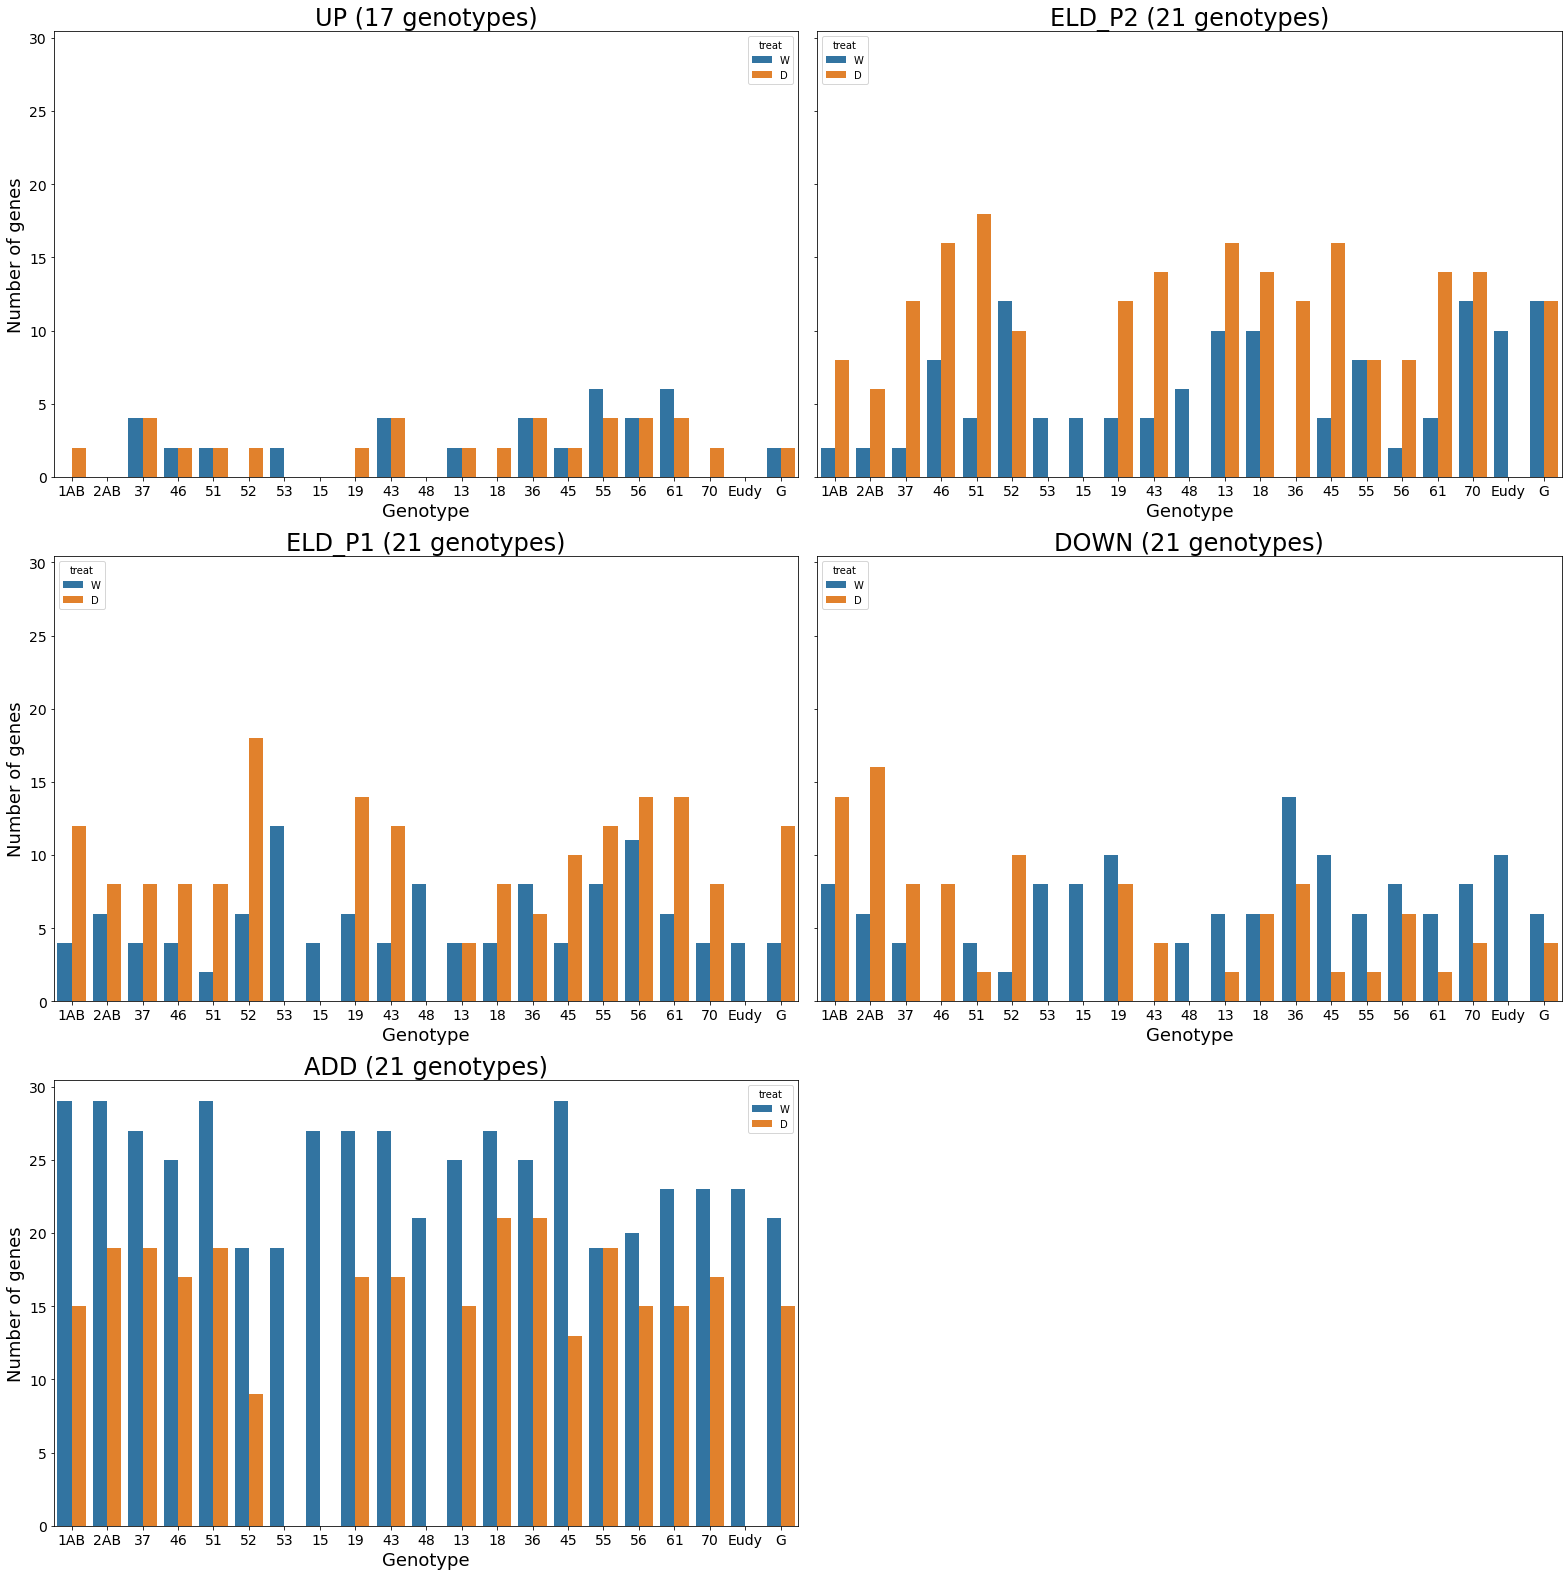

In [96]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)
r=0
c=0
for i in camcounts.sort_values(by="Class",ascending=False)["Class"].unique():
    df = subcounts(camcounts,"Class",i)
    gtx = len(df["genotype"].unique())
    sns.barplot(ax=ax[r,c],data=df,x="genotype",y="syntelogID",hue="treat",order=order)
    ax[r,c].set_title(i+" ("+str(gtx)+" genotypes)",fontsize=24)
    ax[r,c].tick_params(which="both",labelsize=14)
    ax[r,c].set_xlabel("Genotype",fontsize=18)
    if c==0:
        ax[r,c].set_ylabel("Number of genes",fontsize=18)
    else:
        ax[r,c].set_ylabel("")
    
    if c<1:
        c+=1
    else:
        c=0
        r+=1
        
fig.tight_layout()
fig.delaxes(ax[2,1])

plt.savefig("./ncamgenes_gttreat_class.png",dpi=200,bbox_inches="tight")
plt.savefig("./ncamgenes_gttreat_class.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ncamgenes_gttreat_class.svg",dpi=200,bbox_inches="tight")

In [99]:
max(subcounts(camcounts,"Class","UP")["syntelogID"])

6

In [100]:
res.head()

,Gene,Category,Class,lFC_F1_vs_P1,lFC_F1_vs_P2,genotype_treat,genotype,treat,phys
0,recip_syn1000,1,ADD,6.110441,-0.780159,18_D,18,D,C3
1,recip_syn10003,1,ADD,3.313729,-0.887941,18_D,18,D,C3
2,recip_syn10008,1,ADD,1.461161,-0.976261,18_D,18,D,C3
3,recip_syn10061,1,ADD,2.826917,-1.349656,18_D,18,D,C3
4,recip_syn10063,1,ADD,1.728989,-2.551956,18_D,18,D,C3


In [101]:
classcat = res.groupby(["phys","genotype","treat","Class","Category"]).count().reset_index()[["phys","genotype","treat",
                                                                                              "Class","Category","Gene"]]
classcat.head()

,phys,genotype,treat,Class,Category,Gene
0,C3,13,D,ADD,1,1261
1,C3,13,D,ADD,12,583
2,C3,13,D,DOWN,3,261
3,C3,13,D,DOWN,7,682
4,C3,13,D,DOWN,10,254


In [102]:
# sample: subset to DOWN
down = classcat[classcat["Class"]=="DOWN"]

In [122]:
# re-make plot of total partitioned genes, stacking by Category within each Class for each genotype-treatment
def stackplot_catclass(classdf,axc,axs=ax,ctcol="Gene"):
    """
    classdf = the dataframe of counts subset to a single Class
    axs = the overall plotting axis (ax)
    axc = the coordinates on the axis, either single int or tuple of 2 i.e. (0,1)
    """
    
    # find top y position
    topy = classdf.groupby(["genotype","treat","Class"])[ctcol].sum().reset_index()
    
    # drop one category & its counts
    cats = list(classdf["Category"].unique())
    dc = cats[0]
    subdf = classdf[classdf["Category"]!=dc]
    y2 = subdf.groupby(["genotype","treat","Class"])[ctcol].sum().reset_index()
    
    # plot the two stacked bars
    sns.barplot(ax=axs[axc],data=topy,x="genotype",y=ctcol,hue="treat",palette={"W":"darkblue","D":"orangered"},
               legend=False)
    sns.barplot(ax=axs[axc],data=y2,x="genotype",y=ctcol,hue="treat",palette={"W":"tab:blue","D":"tab:orange"},
               legend=False)
    
    # add legend
    tb1 = mpatches.Patch(color='darkblue', label='W cat '+str(dc))
    tb2 = mpatches.Patch(color='orangered', label='D cat '+str(dc))
    mb1 = mpatches.Patch(color="tab:blue",label="W cat "+str(cats[1]))
    mb2 = mpatches.Patch(color="tab:orange",label="D cat "+str(cats[1]))
    
    if len(cats)==3:
        dc2 = cats[1]
        sdf2 = subdf[subdf["Category"]!=dc2]
        y3 = sdf2.groupby(["genotype","treat","Class"])[ctcol].sum().reset_index()
        sns.barplot(ax=axs[axc],data=y3,x="genotype",y=ctcol,hue="treat",palette={"W":"dodgerblue","D":"sandybrown"},
                   legend=False)
        
        # legend for bottom bar
        bb1 = mpatches.Patch(color="dodgerblue", label="W cat "+str(cats[2]))
        bb2 = mpatches.Patch(color="sandybrown", label="D cat "+str(cats[2]))
        plt.legend(handles=[tb1,mb1,bb1,tb2,mb2,bb2])
        plt.show()
    else:
        plt.legend(handles=[tb1,mb1,tb2,mb2])
        plt.show()
        
    

AttributeError: Rectangle.set() got an unexpected keyword argument 'legend'

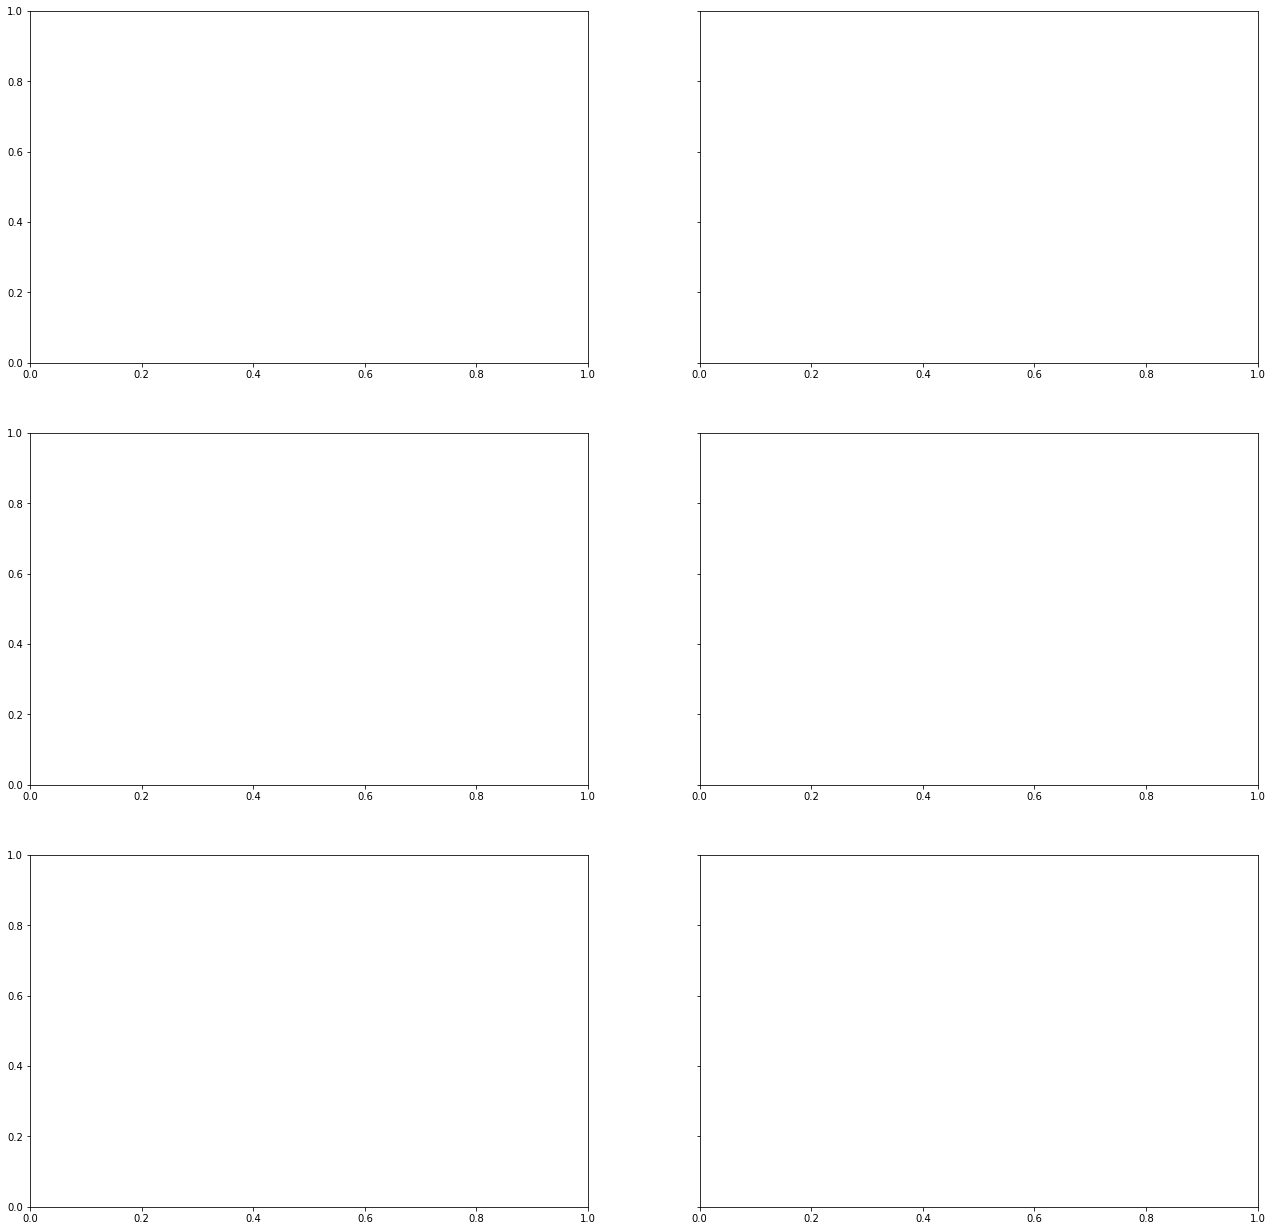

In [123]:
fig,ax = plt.subplots(nrows=3,ncols=2,figsize=(22,22),sharey=True)

stackplot_catclass(down,(0,0),ax)